# CMSC 320 Final Project — Checkpoint 2
## S&P 500 Stock Market EDA

This notebook preprocesses the S&P 500 dataset and explores it with three statistical analyses: descriptive statistics on daily returns, a one-way ANOVA across sectors, and a t-test comparing high vs low volume days.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import f_oneway, ttest_ind

I load three CSV files: daily stock prices, company metadata, and the aggregate index.

In [2]:
stocks    = pd.read_csv('/content/sp500_stocks.csv')
companies = pd.read_csv('/content/sp500_companies.csv')
index     = pd.read_csv('/content/sp500_index.csv')

print(stocks.shape, companies.shape, index.shape)
stocks.head()

(1891536, 8) (502, 16) (2517, 2)


,Date,Symbol,Adj Close,Close,High,Low,Open,Volume
0,2010-01-04,MMM,NaN,NaN,NaN,NaN,NaN,NaN
1,2010-01-05,MMM,NaN,NaN,NaN,NaN,NaN,NaN
2,2010-01-06,MMM,NaN,NaN,NaN,NaN,NaN,NaN
3,2010-01-07,MMM,NaN,NaN,NaN,NaN,NaN,NaN
4,2010-01-08,MMM,NaN,NaN,NaN,NaN,NaN,NaN


Next I parse dates, coerce numeric columns, merge sector labels, and compute daily returns.

In [3]:
stocks['Date'] = pd.to_datetime(stocks['Date'])
for col in ['Open', 'High', 'Low', 'Close', 'Adj Close', 'Volume']:
    stocks[col] = pd.to_numeric(stocks[col], errors='coerce')

stocks.columns    = stocks.columns.str.lower().str.replace(' ', '_')
companies.columns = companies.columns.str.lower().str.replace(' ', '_')

stocks = stocks.sort_values(['symbol', 'date']).reset_index(drop=True)
stocks = stocks.merge(companies[['symbol', 'sector']], on='symbol', how='left')
stocks['daily_return'] = stocks.groupby('symbol')['close'].pct_change()

df = stocks.dropna(subset=['daily_return', 'sector']).copy()
print(df.shape)
df.head()

/tmp/ipykernel_17367/198514948.py:10: FutureWarning: The default fill_method='ffill' in SeriesGroupBy.pct_change is deprecated and will be removed in a future version. Either fill in any non-leading NA values prior to calling pct_change or specify 'fill_method=None' to not fill NA values.
  stocks['daily_return'] = stocks.groupby('symbol')['close'].pct_change()


(617659, 10)


,date,symbol,adj_close,close,high,low,open,volume,sector,daily_return
8291,2013-01-03,ABBV,21.450581,34.830002,35.000000,34.160000,35.000000,16739300.0,Healthcare,-0.008257
8292,2013-01-04,ABBV,21.179594,34.389999,34.889999,34.250000,34.619999,21372100.0,Healthcare,-0.012633
8293,2013-01-07,ABBV,21.222700,34.459999,35.450001,34.150002,34.150002,17897100.0,Healthcare,0.002035
8294,2013-01-08,ABBV,20.760809,33.709999,34.639999,33.360001,34.290001,17863300.0,Healthcare,-0.021764
8295,2013-01-09,ABBV,20.877821,33.900002,33.950001,33.610001,33.610001,18800400.0,Healthcare,0.005636


Overview of the clean dataset:

In [4]:
print('Rows:', df.shape[0], ' Columns:', df.shape[1])
print('Unique stocks:', df['symbol'].nunique())
print('Unique sectors:', df['sector'].nunique())
print('Date range:', df['date'].min().date(), 'to', df['date'].max().date())

Rows: 617659  Columns: 10
Unique stocks: 172
Unique sectors: 11
Date range: 2010-01-05 to 2024-12-20


## Analysis 1: Distribution of Daily Returns

I use descriptive statistics and a histogram to summarize the shape and spread of daily returns across all S&P 500 stocks.

count    617659.000000
mean          0.000652
std           0.020048
min          -0.511559
25%          -0.008210
50%           0.000714
75%           0.009585
max           0.676812
Name: daily_return, dtype: float64


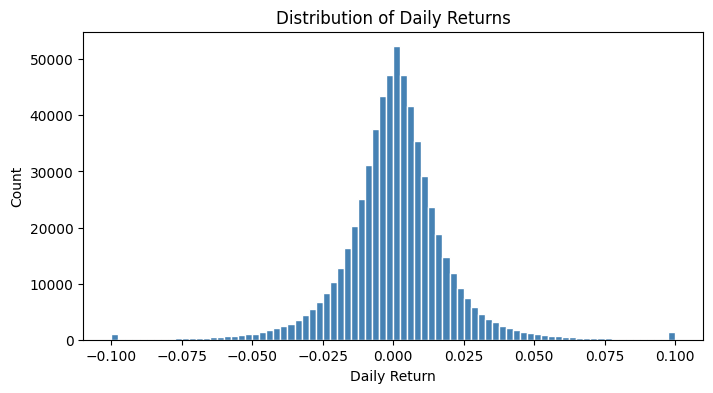

In [5]:
returns = df['daily_return']
print(returns.describe())

plt.figure(figsize=(8, 4))
plt.hist(returns.clip(-0.1, 0.1), bins=80, color='steelblue', edgecolor='white')
plt.xlabel('Daily Return')
plt.ylabel('Count')
plt.title('Distribution of Daily Returns')
plt.show()

The mean daily return is close to zero, and the distribution is roughly bell-shaped, but there are still many extreme positive and negative return days. This tells me that daily returns are not perfectly normal.

## Analysis 2: Do Sectors Have Different Mean Returns? (ANOVA)

I run a one-way ANOVA to test whether mean daily returns differ significantly across the 11 S&P 500 GICS sectors.

F-statistic: 4.2691
p-value: 5.64937244087733e-06


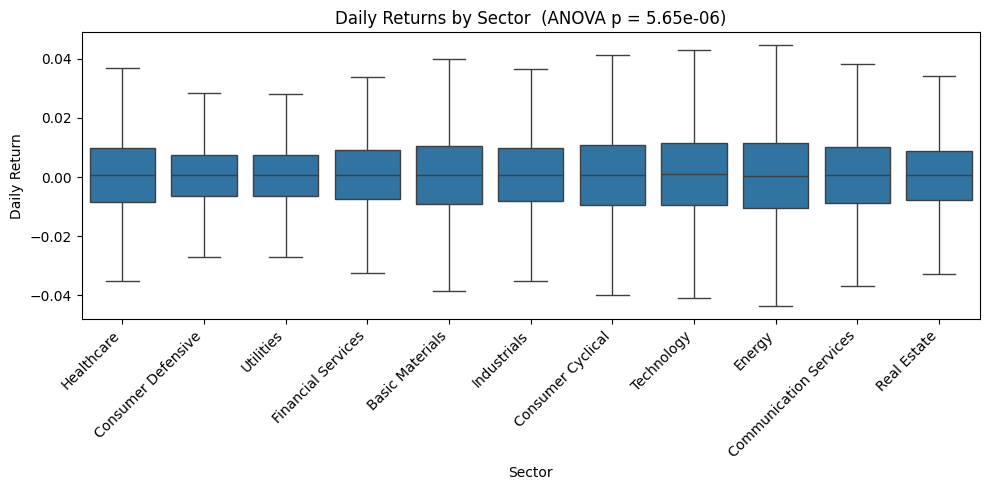

In [6]:
groups = [g['daily_return'].values for _, g in df.groupby('sector')]
stat, p = f_oneway(*groups)
print('F-statistic:', round(stat, 4))
print('p-value:', p)

plt.figure(figsize=(10, 5))
sns.boxplot(data=df, x='sector', y='daily_return', showfliers=False)
plt.xticks(rotation=45, ha='right')
plt.xlabel('Sector')
plt.ylabel('Daily Return')
plt.title(f'Daily Returns by Sector  (ANOVA p = {p:.2e})')
plt.tight_layout()
plt.show()

Since the p-value is much smaller than 0.05, I reject the null hypothesis that all sectors have the same mean daily return. This suggests that average daily returns differ across sectors.

## Analysis 3: High Volume vs Low Volume Days (t-test)

I split trading days at the median volume and use a two-sample t-test to check whether high-volume days tend to produce larger absolute returns than low-volume days.

p-value: 0.000000e+00
high-vol mean: 0.015355
low-vol mean:  0.01086


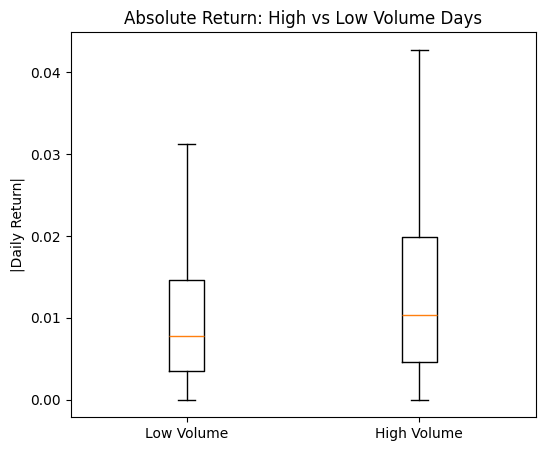

In [9]:
median_vol = df['volume'].median()
high = df[df['volume'] >= median_vol]['daily_return'].abs()
low  = df[df['volume'] <  median_vol]['daily_return'].abs()

stat, p = ttest_ind(high, low, equal_var=False)
print(f"p-value: {p:.6e}")
print('high-vol mean:', round(high.mean(), 6))
print('low-vol mean: ', round(low.mean(), 6))

plt.figure(figsize=(6, 5))
plt.boxplot([low, high], tick_labels=['Low Volume', 'High Volume'], showfliers=False)
plt.ylabel('|Daily Return|')
plt.title('Absolute Return: High vs Low Volume Days')
plt.show()

Since the p-value is much smaller than 0.05, I reject the null hypothesis that high-volume and low-volume days have the same average return magnitude. High-volume days tend to have larger price swings.